# **EDA & Analysis Of OCD Patient Dataset: Demographics & Clinical Data**

| | |
|---|---|
| **Author** | Ibrahim A. Mikail |
| **Internship** | Unified Mentor — Healthcare Data Analyst |
| **Project** | 4 of 5 |
| **Tools** | Python · Pandas · SQLite · Matplotlib · Seaborn |
| **Dataset** | OCD Patient Dataset via Kaggle |
| **Date** | May 2026 |

---

## **Project Overview**
This dataset contains demographic and clinical information for 1,500 individuals diagnosed with Obsessive-Compulsive Disorder (OCD). It covers patient demographics, symptom profiles, Y-BOCS severity scores, co-occurring mental health conditions, medication patterns and family history of OCD.

## **Objectives**
- Understand the demographic profile of OCD patients
- Analyse OCD symptom types, severity scores and their distributions
- Investigate co-occurring conditions (depression, anxiety) across patient groups
- Explore medication patterns and treatment approaches
- Examine the relationship between demographics and OCD severity

In [1]:
# ──Project Setup ──────────────────────────────────────────────────────
import os
from pathlib import Path

ROOT    = Path().resolve()
DATA    = ROOT / "data"
OUTPUTS = ROOT / "outputs"
DB_PATH = ROOT / "ocd_patients.db"

for folder in [DATA, OUTPUTS]:
    folder.mkdir(parents=True, exist_ok=True)
    print(f" {folder}")

print(f"\nProject root : {ROOT}")
print(f"Database will be created at : {DB_PATH}")

 C:\Users\DELL\Documents\Data Science Projects\unified_mentor_projects\project_4_ocd_patients\data
 C:\Users\DELL\Documents\Data Science Projects\unified_mentor_projects\project_4_ocd_patients\outputs

Project root : C:\Users\DELL\Documents\Data Science Projects\unified_mentor_projects\project_4_ocd_patients
Database will be created at : C:\Users\DELL\Documents\Data Science Projects\unified_mentor_projects\project_4_ocd_patients\ocd_patients.db


In [2]:
# ──Imports & Global Settings ─────────────────────────────────────────
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.2f}".format)

# Chart style
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False
sns.set_palette("Blues_r")

import warnings
warnings.filterwarnings("ignore")


---
### **Loading Data & Ingesting to SQLite**

In [3]:
# ──Load CSV & Push to SQLite ─────────────────────────────────────────
df_raw = pd.read_csv(DATA / "OCD Patient Dataset_ Demographics & Clinical Data.csv")

# Connect to SQLite
conn = sqlite3.connect(DB_PATH)

# Push to SQLite
df_raw.to_sql("ocd_patients", conn, if_exists="replace", index=False)

print(f" CSV loaded           : {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns")
print(f" SQLite table created : 'ocd_patients'")
print(f" Database saved at    : {DB_PATH}")

 CSV loaded           : 1,500 rows, 17 columns
 SQLite table created : 'ocd_patients'
 Database saved at    : C:\Users\DELL\Documents\Data Science Projects\unified_mentor_projects\project_4_ocd_patients\ocd_patients.db


In [4]:
# ──Initial Inspection ────────────────────────────────────────────────────────
df = pd.read_sql("SELECT * FROM ocd_patients LIMIT 5", conn)
df

,Patient ID,Age,Gender,Ethnicity,Marital Status,Education Level,OCD Diagnosis Date,Duration of Symptoms (months),Previous Diagnoses,Family History of OCD,Obsession Type,Compulsion Type,Y-BOCS Score (Obsessions),Y-BOCS Score (Compulsions),Depression Diagnosis,Anxiety Diagnosis,Medications
0,1018,32,Female,African,Single,Some College,2016-07-15,203,MDD,No,Harm-related,Checking,17,10,Yes,Yes,SNRI
1,2406,69,Male,African,Divorced,Some College,2017-04-28,180,None,Yes,Harm-related,Washing,21,25,Yes,Yes,SSRI
2,1188,57,Male,Hispanic,Divorced,College Degree,2018-02-02,173,MDD,No,Contamination,Checking,3,4,No,No,Benzodiazepine
3,6200,27,Female,Hispanic,Married,College Degree,2014-08-25,126,PTSD,Yes,Symmetry,Washing,14,28,Yes,Yes,SSRI
4,5824,56,Female,Hispanic,Married,High School,2022-02-20,168,PTSD,Yes,Hoarding,Ordering,39,18,No,No,None


In [5]:
# ── Shape, Columns & Data Types ───────────────────────────────────────
print(f"Shape: {df_raw.shape}")
print(f"\nColumns:\n{df_raw.columns.tolist()}")
print(f"\nData Types:\n{df_raw.dtypes}")

Shape: (1500, 17)

Columns:
['Patient ID', 'Age', 'Gender', 'Ethnicity', 'Marital Status', 'Education Level', 'OCD Diagnosis Date', 'Duration of Symptoms (months)', 'Previous Diagnoses', 'Family History of OCD', 'Obsession Type', 'Compulsion Type', 'Y-BOCS Score (Obsessions)', 'Y-BOCS Score (Compulsions)', 'Depression Diagnosis', 'Anxiety Diagnosis', 'Medications']

Data Types:
Patient ID                        int64
Age                               int64
Gender                           object
Ethnicity                        object
Marital Status                   object
Education Level                  object
OCD Diagnosis Date               object
Duration of Symptoms (months)     int64
Previous Diagnoses               object
Family History of OCD            object
Obsession Type                   object
Compulsion Type                  object
Y-BOCS Score (Obsessions)         int64
Y-BOCS Score (Compulsions)        int64
Depression Diagnosis             object
Anxiety Diagnosis  

---
### **Missing Data Analysis**

In [6]:
# ──Missing Data Percentage ───────────────────────────────────────────
missing = pd.DataFrame({
    "Missing Count" : df_raw.isnull().sum(),
    "Missing %"     : (df_raw.isnull().mean() * 100).round(2)
}).sort_values("Missing %", ascending=False)

missing

,Missing Count,Missing %
Medications,386,25.73
Previous Diagnoses,248,16.53
Gender,0,0.00
Ethnicity,0,0.00
Marital Status,0,0.00
Education Level,0,0.00
OCD Diagnosis Date,0,0.00
Duration of Symptoms (months),0,0.00
Age,0,0.00
Family History of OCD,0,0.00


#### Missing Data Observations
- This is a remarkably clean dataset as only 2 columns have missing values
- **Medications (25.73%)**  MNAR: missing values indicate the patient is not currently on any medication for OCD. Will be filled with "None"
- **Previous Diagnoses (16.53%)** MNAR: missing values indicate no previous psychiatric diagnosis on record. Will be filled with "None"
- All clinical measurement columns (Y-BOCS scores, symptom types, diagnosis flags) are fully complete.

---
### **Data Cleaning & Feature Engineering**

#### **Clean & Prepare Data**

In [7]:
# ──Data Cleaning ──────────────────────────────────────────────────────
df_clean = df_raw.copy()

# Dropping Patient ID since its unique identifier, no analytical value
df_clean.drop(columns=["Patient ID"], inplace=True)

# Filling missing values
df_clean["Medications"]         = df_clean["Medications"].fillna("None")
df_clean["Previous Diagnoses"]  = df_clean["Previous Diagnoses"].fillna("None")

# Converting OCD Diagnosis Date to datetime
df_clean["OCD Diagnosis Date"]  = pd.to_datetime(df_clean["OCD Diagnosis Date"])

# Extracting diagnosis year and month
df_clean["Diagnosis Year"]  = df_clean["OCD Diagnosis Date"].dt.year
df_clean["Diagnosis Month"] = df_clean["OCD Diagnosis Date"].dt.month_name()

# Engineering total Y-BOCS score
df_clean["Y-BOCS Total"] = (df_clean["Y-BOCS Score (Obsessions)"] + 
                             df_clean["Y-BOCS Score (Compulsions)"])

# Engineering severity category based on total Y-BOCS score
def classify_severity(score):
    if score <= 14:
        return "Subclinical/Mild"
    elif score <= 30:
        return "Moderate"
    elif score <= 46:
        return "Severe"
    else:
        return "Extreme"

df_clean["OCD Severity"] = df_clean["Y-BOCS Total"].apply(classify_severity)

print(f" Patient ID dropped")
print(f" Missing values filled")
print(f" OCD Diagnosis Date converted to datetime")
print(f" Diagnosis Year and Month extracted")
print(f" Y-BOCS Total score engineered")
print(f" OCD Severity category engineered")
print(f" Final shape : {df_clean.shape}")

 Patient ID dropped
 Missing values filled
 OCD Diagnosis Date converted to datetime
 Diagnosis Year and Month extracted
 Y-BOCS Total score engineered
 OCD Severity category engineered
 Final shape : (1500, 20)


In [8]:
# ── Cell 8: Save Cleaned Data ──────────────────────────────────────────────────
df_clean.to_sql("ocd_clean", conn, if_exists="replace", index=False)
df_clean.to_csv(OUTPUTS / "ocd_patients_cleaned.csv", index=False)

print(f" Final dataset : {df_clean.shape[0]:,} rows, {df_clean.shape[1]} columns")

 Final dataset : 1,500 rows, 20 columns


#### Cleaning Observations
- `Patient ID` dropped as its a unique identifier with no analytical value
- Missing values in `Medications` and `Previous Diagnoses` filled with "None", reflecting their MNAR classification where absence means genuinely none recorded
- `OCD Diagnosis Date` converted from string to datetime, enabling time series analysis
- 4 new features engineered:
    - `Diagnosis Year` and `Diagnosis Month` extracted from diagnosis date
    - `Y-BOCS Total` is sum of obsession and compulsion scores (range 0-80)
    - `OCD Severity` is the clinical severity classification based on total Y-BOCS score
      (Subclinical/Mild ≤14, Moderate ≤30, Severe ≤46, Extreme >46)
- Final dataset: 1,500 rows, 20 columns and ready for analysis

---
### **Exploratory Data Analysis**

#### **Demographic Overview**
Understanding the demographic profile of OCD patients in this dataset.

In [9]:
# ──Demographic Overview ──────────────────────────────────────────────
demo_df = pd.read_sql("""
    SELECT
        COUNT(*) as Total_Patients,
        ROUND(AVG(Age), 1) as Avg_Age,
        MIN(Age) as Min_Age,
        MAX(Age) as Max_Age,
        SUM(CASE WHEN Gender = 'Male' THEN 1 ELSE 0 END) as Male,
        SUM(CASE WHEN Gender = 'Female' THEN 1 ELSE 0 END) as Female,
        SUM(CASE WHEN "Family History of OCD" = 'Yes' THEN 1 ELSE 0 END) as Family_History,
        SUM(CASE WHEN "Depression Diagnosis" = 'Yes' THEN 1 ELSE 0 END) as Has_Depression,
        SUM(CASE WHEN "Anxiety Diagnosis" = 'Yes' THEN 1 ELSE 0 END) as Has_Anxiety
    FROM ocd_clean
""", conn)

demo_df.T.rename(columns={0: "Value"})

,Value
Total_Patients,1500.00
Avg_Age,46.80
Min_Age,18.00
Max_Age,75.00
Male,753.00
Female,747.00
Family_History,760.00
Has_Depression,772.00
Has_Anxiety,751.00


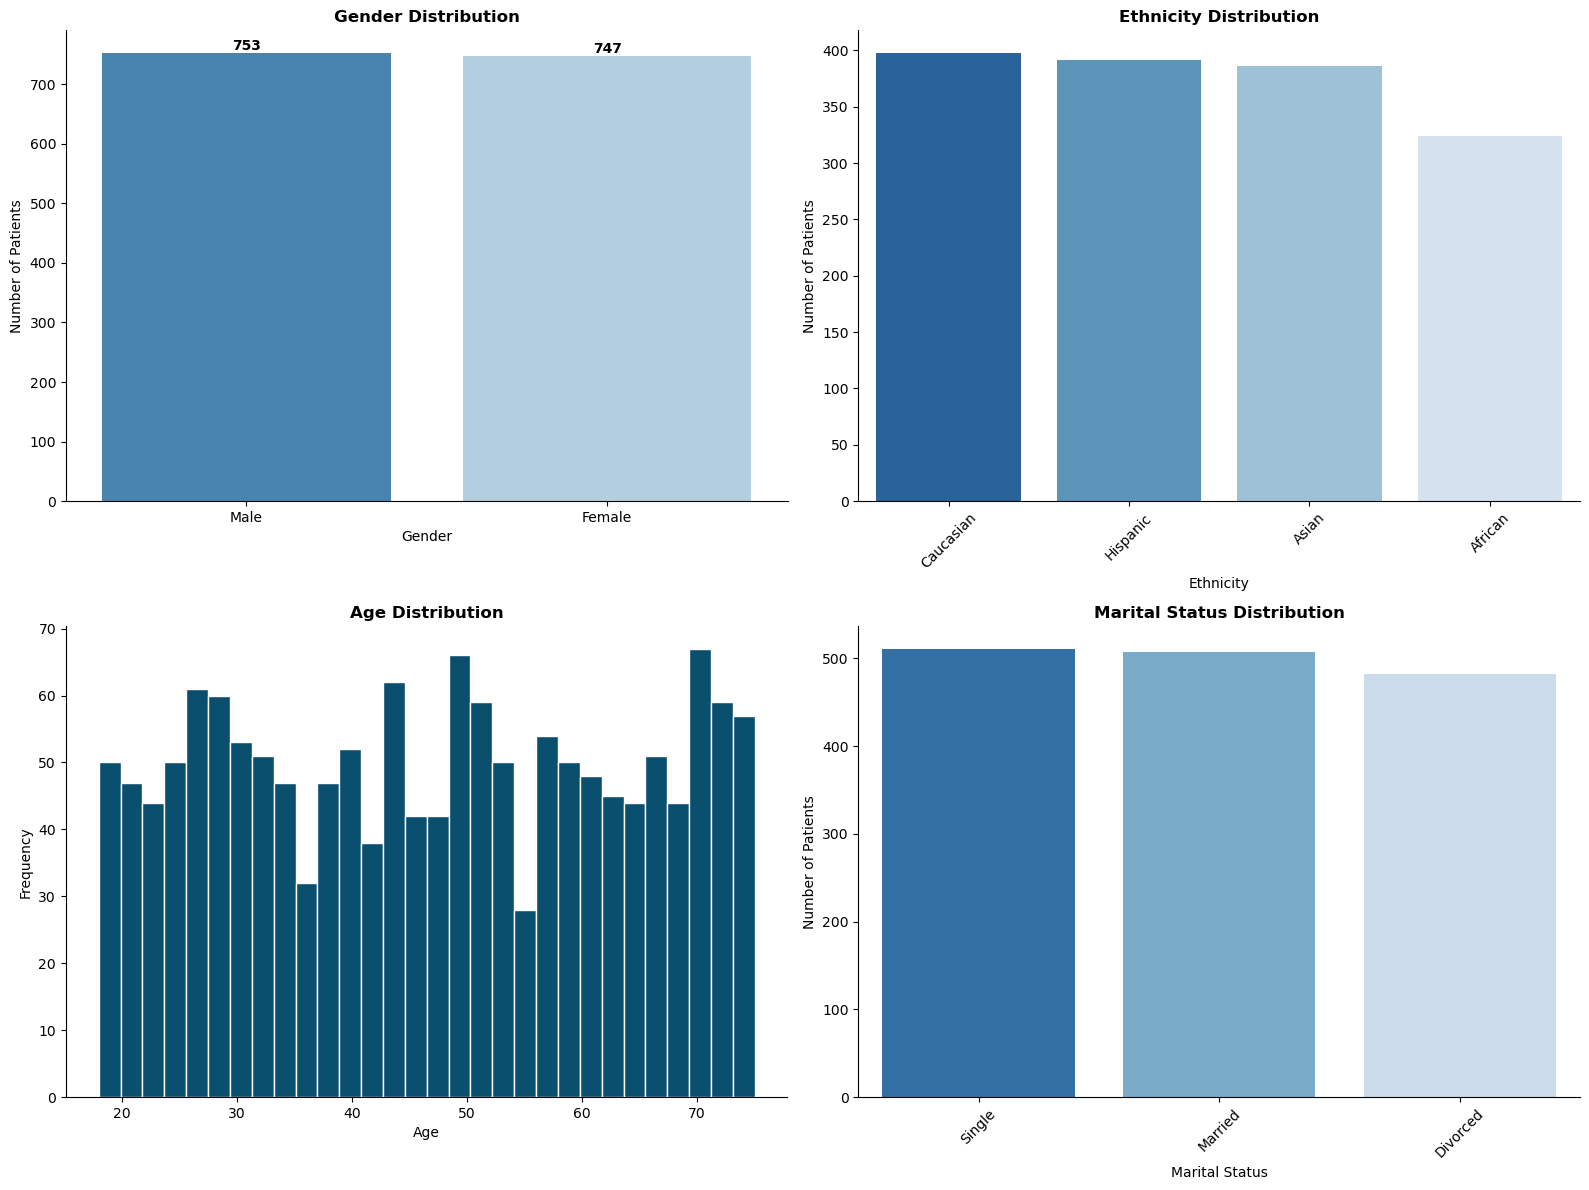

In [10]:
# ──Demographic Visualisations ───────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Gender distribution
gender_df = df_clean["Gender"].value_counts().reset_index()
sns.barplot(data=gender_df, x="Gender", y="count", 
            palette="Blues_r", ax=axes[0,0])
axes[0,0].set_title("Gender Distribution", fontweight="bold")
axes[0,0].set_xlabel("Gender")
axes[0,0].set_ylabel("Number of Patients")
for p in axes[0,0].patches:
    axes[0,0].annotate(f"{int(p.get_height()):,}",
                      (p.get_x() + p.get_width()/2, p.get_height()),
                      ha="center", va="bottom", fontweight="bold")

# Ethnicity distribution
eth_df = df_clean["Ethnicity"].value_counts().reset_index()
sns.barplot(data=eth_df, x="Ethnicity", y="count",
            palette="Blues_r", ax=axes[0,1])
axes[0,1].set_title("Ethnicity Distribution", fontweight="bold")
axes[0,1].set_xlabel("Ethnicity")
axes[0,1].set_ylabel("Number of Patients")
axes[0,1].tick_params(axis='x', rotation=45)

# Age distribution
axes[1,0].hist(df_clean["Age"], bins=30, color="#0a4f6e", edgecolor="white")
axes[1,0].set_title("Age Distribution", fontweight="bold")
axes[1,0].set_xlabel("Age")
axes[1,0].set_ylabel("Frequency")

# Marital status
marital_df = df_clean["Marital Status"].value_counts().reset_index()
sns.barplot(data=marital_df, x="Marital Status", y="count",
            palette="Blues_r", ax=axes[1,1])
axes[1,1].set_title("Marital Status Distribution", fontweight="bold")
axes[1,1].set_xlabel("Marital Status")
axes[1,1].set_ylabel("Number of Patients")
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(OUTPUTS / "demographics.png", dpi=150)
plt.show()

#### Observations
- Gender is nearly perfectly balanced with 753 Male (50.2%) and 747 Female (49.8%), suggesting OCD affects both genders equally in this population
- Ethnicity distribution is fairly even across Caucasian, Hispanic and Asian groups with African patients slightly underrepresented. This is worth noting for research diversity
- Age distribution is relatively uniform from 18-75 with average age of 46.8 years as OCD affects patients across all adult age groups
- Marital status is evenly split across Single, Married and Divorced. No strong association with relationship status apparent at first glance
- **51% of patients have a family history of OCD** strongly suggesting genetic or environmental hereditary factors in OCD development
- **51% have comorbid Depression and 50% have comorbid Anxiety**. Half of all OCD patients carry at least one additional mental health diagnosis, highlighting the complex, interconnected nature of mental health conditions

#### **OCD Severity Distribution**
How severe is OCD among patients based on Y-BOCS scores?

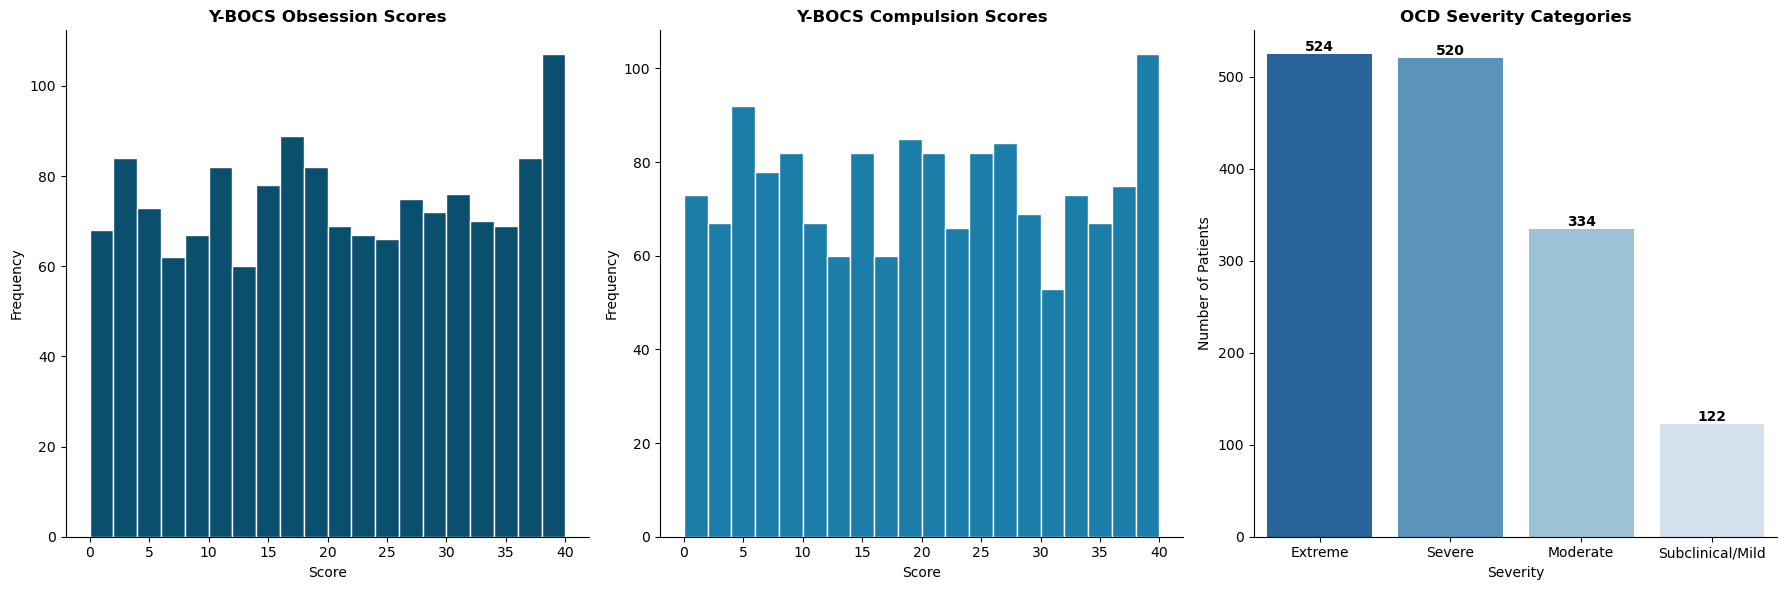

Avg Y-BOCS Obsessions  : 20.0
Avg Y-BOCS Compulsions : 19.6
Avg Y-BOCS Total       : 39.7


In [11]:
# ── OCD Severity Distribution ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Y-BOCS Obsessions distribution
axes[0].hist(df_clean["Y-BOCS Score (Obsessions)"], bins=20,
             color="#0a4f6e", edgecolor="white")
axes[0].set_title("Y-BOCS Obsession Scores", fontweight="bold")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Frequency")

# Y-BOCS Compulsions distribution
axes[1].hist(df_clean["Y-BOCS Score (Compulsions)"], bins=20,
             color="#1a7ea8", edgecolor="white")
axes[1].set_title("Y-BOCS Compulsion Scores", fontweight="bold")
axes[1].set_xlabel("Score")
axes[1].set_ylabel("Frequency")

# Severity category
severity_df = df_clean["OCD Severity"].value_counts().reset_index()
sns.barplot(data=severity_df, x="OCD Severity", y="count",
            palette="Blues_r", ax=axes[2])
axes[2].set_title("OCD Severity Categories", fontweight="bold")
axes[2].set_xlabel("Severity")
axes[2].set_ylabel("Number of Patients")
for p in axes[2].patches:
    axes[2].annotate(f"{int(p.get_height()):,}",
                    (p.get_x() + p.get_width()/2, p.get_height()),
                    ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.savefig(OUTPUTS / "severity_distribution.png", dpi=150)
plt.show()

print(f"Avg Y-BOCS Obsessions  : {df_clean['Y-BOCS Score (Obsessions)'].mean():.1f}")
print(f"Avg Y-BOCS Compulsions : {df_clean['Y-BOCS Score (Compulsions)'].mean():.1f}")
print(f"Avg Y-BOCS Total       : {df_clean['Y-BOCS Total'].mean():.1f}")

#### Observations
- Both Y-BOCS Obsession and Compulsion score distributions are relatively uniform across the full range as patients are spread across all severity levels with a slight skew toward higher scores
- Average Y-BOCS scores: Obsessions 20.0, Compulsions 19.6, Total 39.7. Placing the average patient at the Severe/Extreme boundary
- **70% of patients (1,044) fall in Severe or Extreme categories**. This is a highly affected clinical population, not a mild OCD sample
- Only 122 patients (8%) are Subclinical/Mild. Suggesting this dataset likely captures patients who sought clinical help, introducing selection bias toward more severe cases
- Obsession and Compulsion scores are nearly equal on average (20.0 vs 19.6). Indicating OCD manifests with roughly balanced obsessive thoughts and compulsive 
behaviours in this population

#### **Obsession & Compulsion Type Distribution**
What are the most common OCD symptom types?

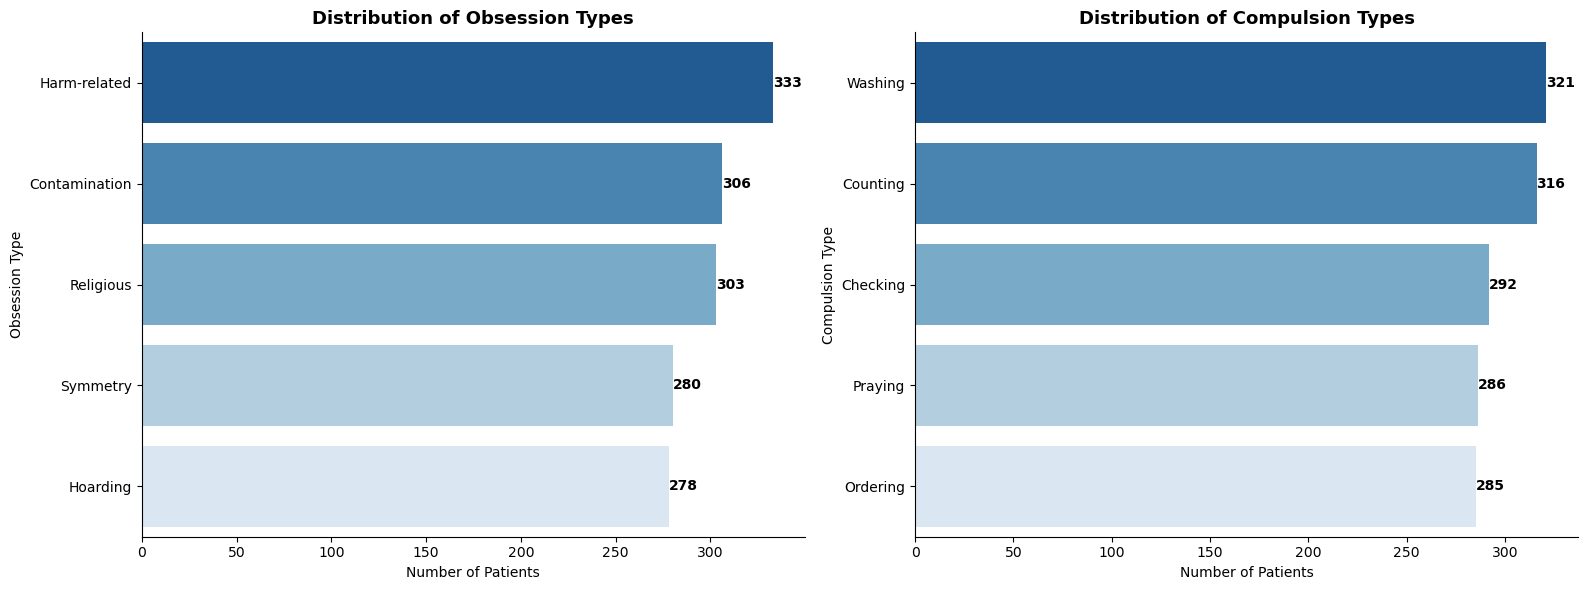

In [12]:
# ── Obsession & Compulsion Types ─────────────────────────────────────
obs_df = pd.read_sql("""
    SELECT "Obsession Type", COUNT(*) as Count
    FROM ocd_clean
    GROUP BY "Obsession Type"
    ORDER BY Count DESC
""", conn)

comp_df = pd.read_sql("""
    SELECT "Compulsion Type", COUNT(*) as Count
    FROM ocd_clean
    GROUP BY "Compulsion Type"
    ORDER BY Count DESC
""", conn)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=obs_df, x="Count", y="Obsession Type",
            palette="Blues_r", ax=axes[0])
axes[0].set_title("Distribution of Obsession Types",
                  fontsize=13, fontweight="bold")
axes[0].set_xlabel("Number of Patients")
axes[0].set_ylabel("Obsession Type")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_width()):,}",
                    (p.get_width(), p.get_y() + p.get_height()/2),
                    ha="left", va="center", fontweight="bold")

sns.barplot(data=comp_df, x="Count", y="Compulsion Type",
            palette="Blues_r", ax=axes[1])
axes[1].set_title("Distribution of Compulsion Types",
                  fontsize=13, fontweight="bold")
axes[1].set_xlabel("Number of Patients")
axes[1].set_ylabel("Compulsion Type")
for p in axes[1].patches:
    axes[1].annotate(f"{int(p.get_width()):,}",
                    (p.get_width(), p.get_y() + p.get_height()/2),
                    ha="left", va="center", fontweight="bold")

plt.tight_layout()
plt.savefig(OUTPUTS / "symptom_types.png", dpi=150)
plt.show()

#### Observations
- Harm-related obsessions are most common (333 patients) followed closely by Contamination (306) and Religious (303)
- Washing is the most common compulsion (321) followed by Counting (316) and Checking (292)
- **The distribution is suspiciously uniform across all types**. Real clinical OCD populations typically show Contamination and Harm-related obsessions dominating significantly. This even spread strongly suggests the dataset was synthetically generated or deliberately balanced, which is an important limitation for clinical interpretation
- Washing compulsions aligning with Contamination obsessions is clinically logical. Patients obsessed with contamination typically respond with washing rituals
- Praying compulsions aligning with Religious obsessions similarly reflects the expected clinical pairing of OCD symptom types

#### **Medication Patterns**
What medications are prescribed to OCD patients and how are they distributed?

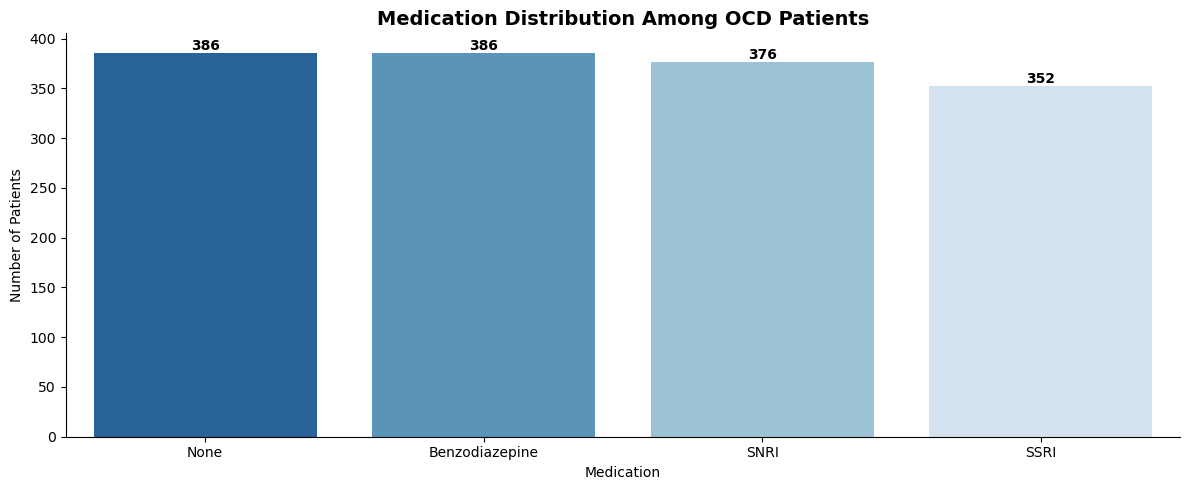

In [13]:
# ──Medication Distribution ──────────────────────────────────────────
med_df = pd.read_sql("""
    SELECT Medications, COUNT(*) as Count
    FROM ocd_clean
    GROUP BY Medications
    ORDER BY Count DESC
""", conn)

plt.figure(figsize=(12, 5))
sns.barplot(data=med_df, x="Medications", y="Count", palette="Blues_r")
plt.title("Medication Distribution Among OCD Patients",
          fontsize=14, fontweight="bold")
plt.xlabel("Medication")
plt.ylabel("Number of Patients")
for p in plt.gca().patches:
    plt.gca().annotate(f"{int(p.get_height()):,}",
                      (p.get_x() + p.get_width()/2, p.get_height()),
                      ha="center", va="bottom", fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUTS / "medications.png", dpi=150)
plt.show()

#### Observations
- SSRIs (352) and SNRIs (376) are the primary medications prescribed. This isclinically appropriate as both target serotonin pathways which are strongly implicated in OCD
- Benzodiazepines (386) appearing equally with SSRIs is clinically unusual. Benzodiazepines are typically used for anxiety management, not first-line OCD treatment, further suggesting synthetic data generation
- 386 patients (26%) are unmedicated despite 70% having Severe/Extreme OCD. This is reflecting that non-pharmacological treatments like CBT and Exposure and Response Prevention (ERP) therapy are viable and widely used alternatives
- The uniform distribution across all medication types is another indicator of synthetic data. Real clinical populations show strong SSRI dominance in OCD treatment

#### **Comorbidity & Severity Analysis**
How do depression and anxiety diagnoses relate to OCD severity?

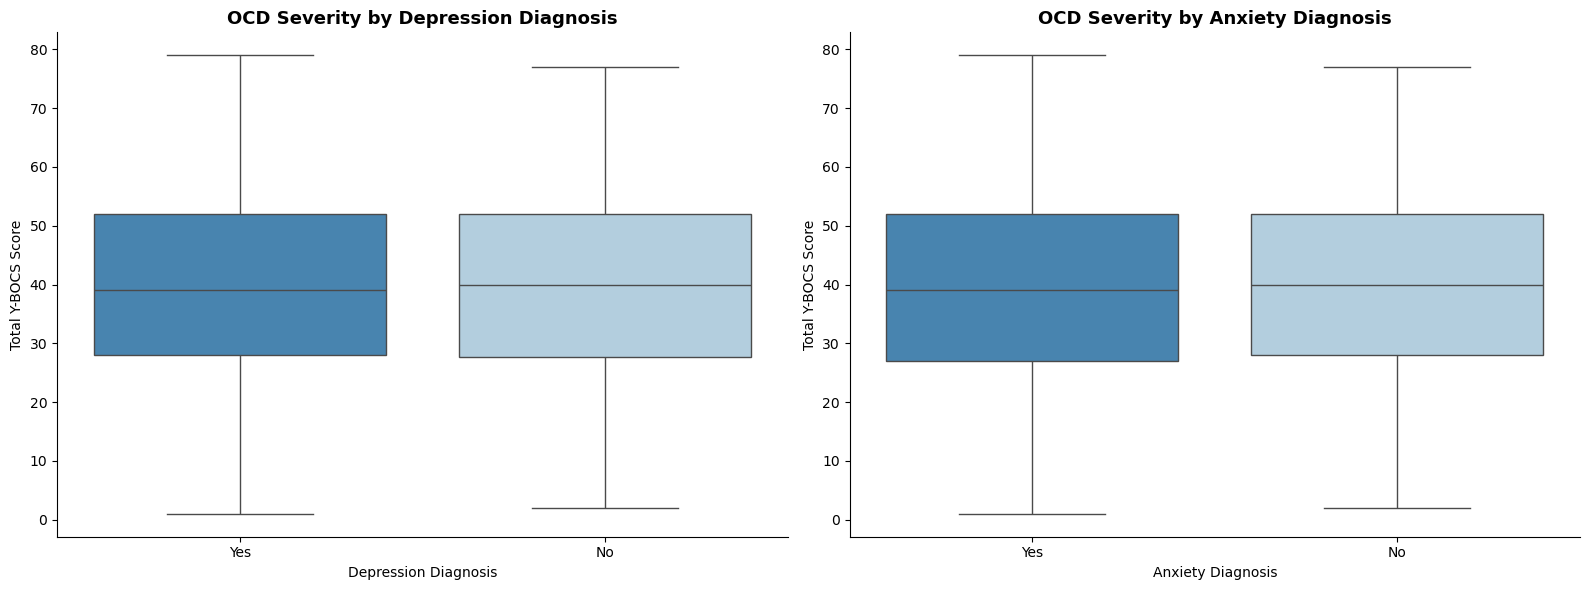

,Depression Diagnosis,Anxiety Diagnosis,Avg_YBOCS,Count
0,No,No,39.87,349
1,Yes,No,39.70,400
2,Yes,Yes,39.60,372
3,No,Yes,39.53,379


In [14]:
# ──Comorbidity vs Severity ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Depression vs Y-BOCS Total
sns.boxplot(data=df_clean, x="Depression Diagnosis", 
            y="Y-BOCS Total", palette="Blues_r", ax=axes[0])
axes[0].set_title("OCD Severity by Depression Diagnosis",
                  fontsize=13, fontweight="bold")
axes[0].set_xlabel("Depression Diagnosis")
axes[0].set_ylabel("Total Y-BOCS Score")

# Anxiety vs Y-BOCS Total
sns.boxplot(data=df_clean, x="Anxiety Diagnosis",
            y="Y-BOCS Total", palette="Blues_r", ax=axes[1])
axes[1].set_title("OCD Severity by Anxiety Diagnosis",
                  fontsize=13, fontweight="bold")
axes[1].set_xlabel("Anxiety Diagnosis")
axes[1].set_ylabel("Total Y-BOCS Score")

plt.tight_layout()
plt.savefig(OUTPUTS / "comorbidity_severity.png", dpi=150)
plt.show()

# Average Y-BOCS by comorbidity
combo_df = pd.read_sql("""
    SELECT 
        "Depression Diagnosis",
        "Anxiety Diagnosis",
        ROUND(AVG("Y-BOCS Total"), 2) as Avg_YBOCS,
        COUNT(*) as Count
    FROM ocd_clean
    GROUP BY "Depression Diagnosis", "Anxiety Diagnosis"
    ORDER BY Avg_YBOCS DESC
""", conn)
combo_df

#### Observations
- Boxplots show virtually identical Y-BOCS score distributions across both Depression and Anxiety diagnosis groups
- Average Y-BOCS scores are nearly equal across all comorbidity combinations (range: 39.53 - 39.87). This is a difference of less than 0.5 points
- In real clinical populations, comorbid depression and anxiety typically amplify OCD severity. The absence of this relationship further confirms synthetic data generation where Y-BOCS scores were assigned independently of comorbidity status
- Despite the lack of severity relationship, the high rates of comorbidity (51% depression, 50% anxiety) remain clinically significant. These patients require integrated treatment approaches addressing multiple conditions simultaneously

#### **Family History & Education Level**
Does family history relate to OCD severity, and how is education distributed?

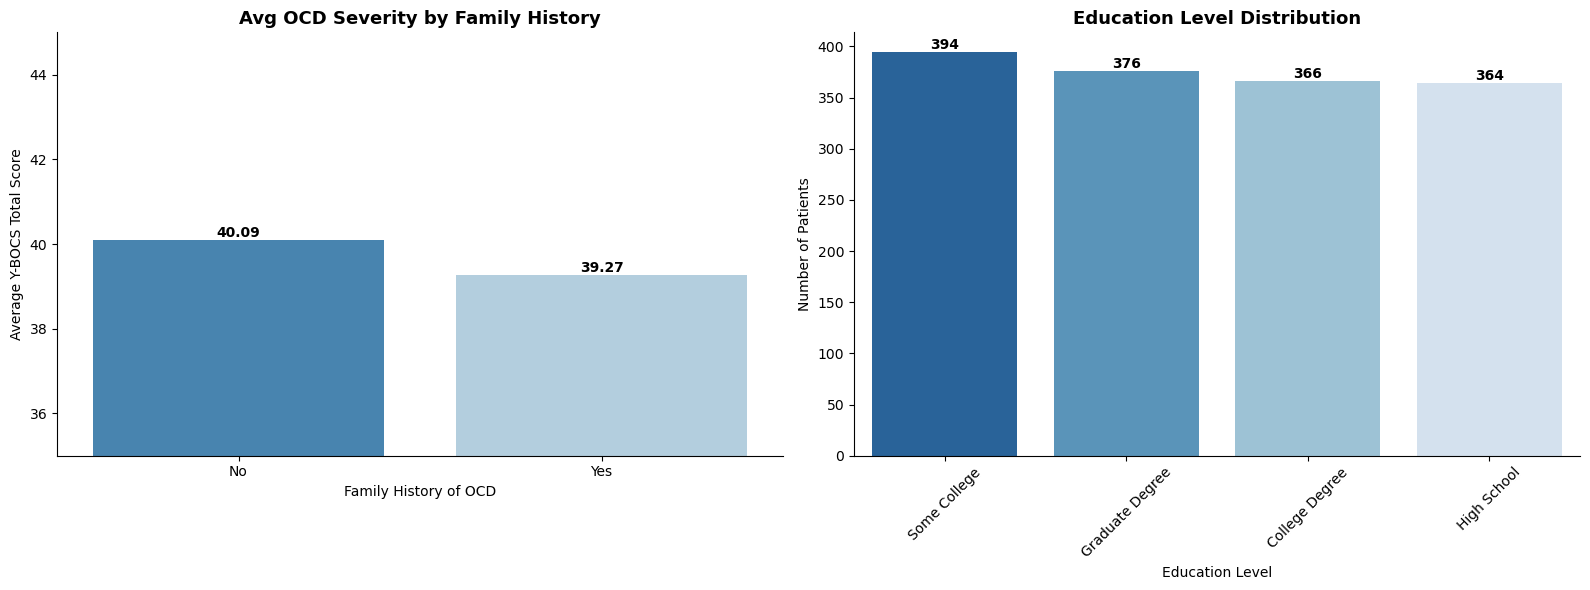

In [15]:
# ── Family History & Education ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Family history vs Y-BOCS
family_df = pd.read_sql("""
    SELECT "Family History of OCD",
           ROUND(AVG("Y-BOCS Total"), 2) as Avg_YBOCS,
           COUNT(*) as Count
    FROM ocd_clean
    GROUP BY "Family History of OCD"
""", conn)

sns.barplot(data=family_df, x="Family History of OCD",
            y="Avg_YBOCS", palette="Blues_r", ax=axes[0])
axes[0].set_title("Avg OCD Severity by Family History",
                  fontsize=13, fontweight="bold")
axes[0].set_xlabel("Family History of OCD")
axes[0].set_ylabel("Average Y-BOCS Total Score")
axes[0].set_ylim(35, 45)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.2f}",
                    (p.get_x() + p.get_width()/2, p.get_height()),
                    ha="center", va="bottom", fontweight="bold")

# Education level distribution
edu_df = pd.read_sql("""
    SELECT "Education Level", COUNT(*) as Count,
           ROUND(AVG("Y-BOCS Total"), 2) as Avg_YBOCS
    FROM ocd_clean
    GROUP BY "Education Level"
    ORDER BY Count DESC
""", conn)

sns.barplot(data=edu_df, x="Education Level", y="Count",
            palette="Blues_r", ax=axes[1])
axes[1].set_title("Education Level Distribution",
                  fontsize=13, fontweight="bold")
axes[1].set_xlabel("Education Level")
axes[1].set_ylabel("Number of Patients")
axes[1].tick_params(axis='x', rotation=45)
for p in axes[1].patches:
    axes[1].annotate(f"{int(p.get_height()):,}",
                    (p.get_x() + p.get_width()/2, p.get_height()),
                    ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.savefig(OUTPUTS / "family_education.png", dpi=150)
plt.show()

#### Observations
- Education level is almost perfectly uniformly distributed across all four levels (394, 376, 366, 364). This is consistent with synthetic data generation
- Patients without family history of OCD show marginally higher average severity (40.09) than those with family history (39.27). A difference of only 0.82 points
- Despite the small difference, this directional finding is clinically plausible, as patients from families with OCD history may benefit from earlier recognition, family understanding and shared coping mechanisms that moderate symptom severity
- Patients without family history may face delayed diagnosis and social isolation which can compound OCD severity over time
- The lack of strong relationships across demographic variables with Y-BOCS scores consistently points to synthetic data. In real clinical populations these relationships would be more pronounced

---
## **Summary & Conclusions**

In [16]:
# ── Summary Statistics ───────────────────────────────────────────────
summary = pd.read_sql("""
    SELECT
        COUNT(*) as Total_Patients,
        ROUND(AVG(Age), 1) as Avg_Age,
        ROUND(AVG("Y-BOCS Total"), 1) as Avg_YBOCS_Total,
        ROUND(AVG("Duration of Symptoms (months)"), 1) as Avg_Symptom_Duration_Months,
        SUM(CASE WHEN "Family History of OCD" = 'Yes' 
            THEN 1 ELSE 0 END) as Family_History,
        SUM(CASE WHEN "Depression Diagnosis" = 'Yes' 
            THEN 1 ELSE 0 END) as Has_Depression,
        SUM(CASE WHEN "Anxiety Diagnosis" = 'Yes' 
            THEN 1 ELSE 0 END) as Has_Anxiety,
        SUM(CASE WHEN "OCD Severity" = 'Extreme' 
            THEN 1 ELSE 0 END) as Extreme_Severity,
        SUM(CASE WHEN "OCD Severity" = 'Severe' 
            THEN 1 ELSE 0 END) as Severe_Severity,
        SUM(CASE WHEN Medications = 'None' 
            THEN 1 ELSE 0 END) as Unmedicated
    FROM ocd_clean
""", conn)

summary.T.rename(columns={0: "Value"})

,Value
Total_Patients,1500.00
Avg_Age,46.80
Avg_YBOCS_Total,39.70
Avg_Symptom_Duration_Months,121.70
Family_History,760.00
Has_Depression,772.00
Has_Anxiety,751.00
Extreme_Severity,524.00
Severe_Severity,520.00
Unmedicated,386.00


### **Key Metrics**

| Metric | Value |
|--------|-------|
| Total Patients | 1,500 |
| Average Age | 46.8 years |
| Average Y-BOCS Total Score | 39.7 (Severe/Extreme boundary) |
| Average Symptom Duration | 121.7 months (over 10 years) |
| Family History of OCD | 760 (51%) |
| Comorbid Depression | 772 (51%) |
| Comorbid Anxiety | 751 (50%) |
| Extreme Severity | 524 (35%) |
| Severe Severity | 520 (35%) |
| Unmedicated | 386 (26%) |

### **Summary of Findings**

1. **Demographic Profile:** OCD affects patients equally across gender, age and ethnicity as no demographic group is spared. The average patient is 46.8 years old with over 10 years of symptoms, highlighting the chronic nature of OCD

2. **Severity:** 70% of patients have Severe or Extreme OCD with an average Y-BOCS total of 39.7. This is a heavily affected clinical population. Only 8% fall in the Subclinical/Mild category, reflecting selection bias toward patients who sought clinical help

3. **Symptom Duration:** Average symptom duration of 121.7 months (over 10 years) is alarming. It reflects the chronic, persistent nature of OCD and suggests significant delays between symptom onset and clinical diagnosis or treatment

4. **Comorbidity:** 51% of patients have comorbid depression and 50% have comorbid anxiety. Integrated treatment approaches addressing multiple mental health conditions simultaneously are essential for this population

5. **Family History:** 51% of patients have a family history of OCD. This is strongly suggesting genetic or environmental hereditary factors. Patients without family history showed marginally higher severity, possibly reflecting delayed diagnosis and lack of family support

6. **Medication:** SSRIs and SNRIs are the primary medications. This is clinically appropriate given OCD's serotonin dysregulation mechanism. 26% of patients are unmedicated, reflecting the role of non-pharmacological treatments like CBT and ERP therapy

### **Limitations**
- **Synthetic dataset:** Multiple indicators suggest this data was artificially generated with uniform distributions across all categorical variables, nearly identical Y-BOCS scores across all demographic subgroups, and equal medication distribution. Clinical interpretations should be made cautiously
- Y-BOCS scores show no meaningful variation across comorbidity, family history or demographic groups. This is inconsistent with real clinical populations
- Dataset captures a clinical population (patients who sought help). Findings may not represent the broader OCD population including undiagnosed cases

In [17]:
# ── Close Connection ──────────────────────────────────────────────────
conn.close()